In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [149]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [150]:
df = pd.read_csv(r"C:\Users\Dell\Documents\AI_EDA\AI_Impact_Student_Life_2026.csv")

In [151]:
df.head()

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9


In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1500 non-null   str    
 1   Age                      1500 non-null   int64  
 2   Major                    1500 non-null   str    
 3   Primary_AI_Tool          1500 non-null   str    
 4   Task_Frequency_Daily     1500 non-null   int64  
 5   Main_Usage_Case          1500 non-null   str    
 6   GPA_Baseline             1500 non-null   float64
 7   GPA_Post_AI              1500 non-null   float64
 8   Time_Saved_Hours_Weekly  1500 non-null   int64  
 9   AI_Ethics_Concern        1500 non-null   str    
 10  Career_Confidence_Score  1500 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 129.0 KB


In [153]:
df.duplicated().sum()

np.int64(0)

In [154]:
df.isnull().sum()


Student_ID                 0
Age                        0
Major                      0
Primary_AI_Tool            0
Task_Frequency_Daily       0
Main_Usage_Case            0
GPA_Baseline               0
GPA_Post_AI                0
Time_Saved_Hours_Weekly    0
AI_Ethics_Concern          0
Career_Confidence_Score    0
dtype: int64

In [155]:
df 

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9
...,...,...,...,...,...,...,...,...,...,...,...
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7


In [156]:
df_Major

,count
Major,
Fine Arts,263
Data Science,259
Biology,259
Business Administration,256
Software Engineering,242
Modern History,221


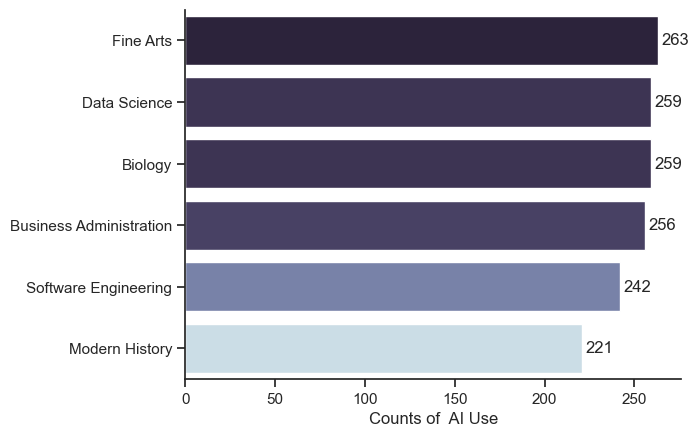

In [157]:
df_Major = df['Major'].value_counts().to_frame(name='count')
sns.barplot(df_Major,x='count',y=df_Major.index,hue='count',legend=False,palette="ch:s=.25,rot=-.25")
sns.despine()
plt.ylabel('')
plt.xlabel('Counts of  AI Use')
ax=plt.gca()
for i,(major,value)in enumerate(df_Major['count'].items()):
    ax.text(value+2,i,str(value),va='center')


In [158]:
df

,Student_ID,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
0,STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
1,STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
2,STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
3,STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
4,STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9
...,...,...,...,...,...,...,...,...,...,...,...
1495,STU-2711,21,Modern History,GitHub Copilot,4,Brainstorming,3.35,3.55,7,Medium,7
1496,STU-4888,21,Biology,GitHub Copilot,3,Essay Drafting,3.59,3.89,13,Medium,7
1497,STU-0180,23,Software Engineering,GitHub Copilot,8,Code Debugging,3.20,3.40,7,Low,2
1498,STU-4392,23,Fine Arts,Perplexity,6,Brainstorming,3.99,4.00,15,Low,7


In [159]:
df_AI = df['Primary_AI_Tool'].value_counts().copy()

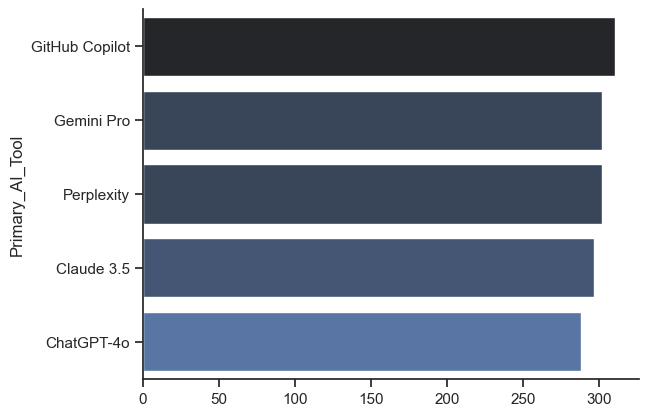

In [163]:
sns.barplot(x=df_AI.values,y=df_AI.index,hue=df_AI.values,legend=False,palette='dark:b_r')
sns.despine()
plt.figure(figsize=(12,6))
sns.set_theme(style='ticks')
plt.ylabel("")
plt.xlabel('Count of Users')
plt.title('Top AI Tools')
for i,(tool,value) in enumerate(df_AI.items()):
    plt.text(value+1,i,str(value))
